In [1]:
import numpy as np
import lal
import lalsimulation as ls
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform
from bilby.gw.conversion import chirp_mass_and_mass_ratio_to_component_masses,component_masses_to_chirp_mass
import bilby
import dill
from pycbc.detector import Detector
import sys
sys.path.append('/Users/nehasharma/Relative-binning-time-domain/Relative_binning_class/')
from Relative_22_H1_frame import *
from Exact_H1_frame import *

/var/folders/p2/c6t1fjt53c1c56rmnmzgz0_00000gn/T/ipykernel_33036/938556794.py:2: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


/Users/nehasharma/local/lalsuite/lib/python3.13/site-packages/lalsimulation/__init__.py
/Users/nehasharma/local/lalsuite/lib/python3.13/site-packages/lalsimulation/__init__.py


In [2]:
import logging
bilby.core.utils.logger.setLevel(logging.CRITICAL)

In [3]:
priors = bilby.gw.prior.CBCPriorDict(
    dict(
        chirp_mass=bilby.core.prior.Uniform(
            minimum=40,
            maximum=60,
            name="chirp_mass",
            latex_label="$\\mathcal{M}$",
        ),
        mass_ratio=bilby.core.prior.Uniform(
            minimum=1 / 6,
            maximum=1.0,
            name="mass_ratio",
            latex_label="$q$",
        ),
        chi_1=bilby.core.prior.Uniform(
            minimum=-0.99,
            maximum=0.99,
            name="chi_1",
            latex_label="$\\chi_1$",
        ),
        chi_2=bilby.core.prior.Uniform(
            minimum=-0.99,
            maximum=0.99,
            name="chi_2",
            latex_label="$\\chi_2$",
        ),
        luminosity_distance=bilby.gw.prior.UniformSourceFrame(
            name="luminosity_distance", minimum=1e1, maximum=3000, unit="Mpc"
        ),
        theta_jn=bilby.core.prior.Sine(name="theta_jn"),
        ra=bilby.core.prior.Uniform(
            minimum=0, maximum=2 * np.pi, name="ra", boundary="periodic"
        ),
        dec=bilby.core.prior.Cosine(name="dec"),
        psi=bilby.core.prior.Uniform(
            minimum=0, maximum=np.pi, name="psi", boundary="periodic"
        ),
        phase=bilby.core.prior.Uniform(
            minimum=0, maximum=2 * np.pi, name="phase", boundary="periodic"
        ),
        geocent_time=bilby.core.prior.Uniform(
            1126259462.413 - 0.1,
            1126259462.413 + 0.1,
            name="geocent_time",
            latex_label="$t_c$",
        ),
    )
)

In [4]:
def SNR_using_bilby(fiducial_parameters):
    duration = 4.0
    sampling_frequency = 4096.0
    minimum_frequency = 20

    injection_parameters2 = fiducial_parameters.copy()
    injection_parameters2["mass_1"], injection_parameters2["mass_2"] = (
        chirp_mass_and_mass_ratio_to_component_masses(
            injection_parameters2["chirp_mass"], injection_parameters2["mass_ratio"]
        )
    )
    injection_parameters2.pop("chirp_mass")
    injection_parameters2.pop("mass_ratio")

    # Fixed arguments passed into the source model
    waveform_arguments = dict(
        waveform_approximant="IMRPhenomT",
        reference_frequency=20,
        minimum_frequency=minimum_frequency,
    )

    # Create the waveform_generator using a LAL BinaryBlackHole source function
    waveform_generator = bilby.gw.WaveformGenerator(
        duration=duration,
        sampling_frequency=sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
        parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
        waveform_arguments=waveform_arguments,
        parameters=injection_parameters2,
    )

    # Set up interferometers.  In this case we'll use two interferometers
    # (LIGO-Hanford (H1), LIGO-Livingston (L1). These default to their design
    # sensitivity
    ifos = bilby.gw.detector.InterferometerList(["H1", "L1","V1"])
    ifos[0].minimum_frequency = 20
    ifos[1].minimum_frequency = 20
    ifos.set_strain_data_from_zero_noise(
        sampling_frequency=sampling_frequency,
        duration=duration,
        start_time=fiducial_parameters["geocent_time"],
    )
    ifos.inject_signal(
        waveform_generator=waveform_generator, parameters=injection_parameters2
    )
    likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
        interferometers=ifos,
        waveform_generator=waveform_generator,
        time_reference = "H1"
    )
    return {
        "H1": ifos.meta_data["H1"]["matched_filter_SNR"].real,
        "L1": ifos.meta_data["L1"]["matched_filter_SNR"].real,
        "V1": ifos.meta_data["V1"]["matched_filter_SNR"].real
    }, np.sqrt(
        (ifos.meta_data["L1"]["matched_filter_SNR"].real) ** 2
        + (ifos.meta_data["H1"]["matched_filter_SNR"].real) ** 2
    + (ifos.meta_data["V1"]["matched_filter_SNR"].real) ** 2),likelihood

## Check 1: Comparison between Relative binning and Exact Likelihood (only 22 mode)

In [5]:
with open("/Users/nehasharma/Relative-binning-time-domain/ACF_noise_and_covariance_matrix_data/x_and_y_2_sec.pkl", "rb") as f:
    x_and_y = dill.load(f)

In [6]:
x = x_and_y["x"]
y = x_and_y["y"]

In [7]:
Detectors_list = {"H1":Detector("H1"),"L1":Detector("L1"),"V1":Detector("V1")}
Noise= {"H1":0,"L1":0,"V1":0}
Data_list = {}

In [8]:
injection_parameters = priors.sample()
Time_array = np.arange(-2 + 0.5, 0.5, 1 / 4096.0, dtype=np.float64)

In [9]:
injection_parameters

{'chirp_mass': 41.772987667608156,
 'mass_ratio': 0.6592873179037878,
 'chi_1': 0.9640379388988336,
 'chi_2': -0.7056285021021997,
 'luminosity_distance': 2430.812277677927,
 'theta_jn': np.float64(1.0203115121528255),
 'ra': 4.778465893172366,
 'dec': np.float64(0.9143198524791907),
 'psi': 2.5491069958871853,
 'phase': 3.5859680638726648,
 'geocent_time': 1126259462.4035408}

In [10]:
SNR_bilby = SNR_using_bilby(injection_parameters)[0] # frequency domain

In [11]:
SNR_bilby

{'H1': np.float64(8.862378665809137),
 'L1': np.float64(6.766124373850774),
 'V1': np.float64(5.653394763308523)}

In [12]:
to_h1 = Detector('H1').time_delay_from_earth_center(injection_parameters['ra'], injection_parameters['dec'], injection_parameters['geocent_time'])
injection_parameters["H1_time"] = injection_parameters["geocent_time"] + to_h1   # New parameter H1_time : arrival time in detector H1
priors["H1_time"] = bilby.core.prior.Uniform(
            injection_parameters["H1_time"] - 0.01,
            injection_parameters["H1_time"] + 0.01,
            name="H1_time",
            latex_label="$t_{H1}$",
            unit=None,
            boundary=None,
        )
injection_parameters.pop("geocent_time")
fiducial_parameters = injection_parameters.copy()

In [13]:
epsilon1_H1, epsilon2_H1 = 0.5,0.1
epsilon1_L1, epsilon2_L1 = 0.5,0.1
epsilon1_V1, epsilon2_V1 = 0.5,0.1

spacing1, spacing2, spacing3,spacing_times1,spacing_times2 = 1, 10, 100,0.02, 0.2

spacing = [spacing1, spacing2, spacing3]
epsilon = {"H1":np.array([epsilon1_H1,epsilon2_H1]),"L1":np.array([epsilon1_L1,epsilon2_L1]),"V1":np.array([epsilon1_V1,epsilon2_V1])}
spacing_times = [spacing_times1, spacing_times2]

In [14]:
Likelihood_obj = RelativeBinningTimeDomainH1detectorframe(
    time = Time_array,
    Detectors_list = Detectors_list,
    fiducial_parameters = fiducial_parameters,
    injection_parameters = injection_parameters,
    Data_list = Data_list,
    x = x,
    y = y,
    Noise = Noise,
    fmin = 10,
    fref = 20,
    epsilon_array_per_detector=epsilon,
    spacing=spacing,
    spacing_times=spacing_times
)
SNR, Network_SNR = Likelihood_obj.compute_SNR_TD_and_waveform_data()[0:2]

In [15]:
Likelihood_obj.number_of_bins

{'H1': 242, 'L1': 242, 'V1': 268}

In [16]:
Likelihood_obj_exact = ExactLikelihoodTimeDomainH1detectorframe(
    time = Time_array,
    Detectors_list = Detectors_list,
    injection_parameters = injection_parameters,
    Data_list = Data_list,
    x = x,
    y = y,
    Noise = Noise,
    fmin = 10,
    fref = 20,
)
SNR_exact, Network_SNR_exact = Likelihood_obj_exact.compute_SNR_TD_and_waveform_data()[0:2]

2 2


(-0.1, 0.1)

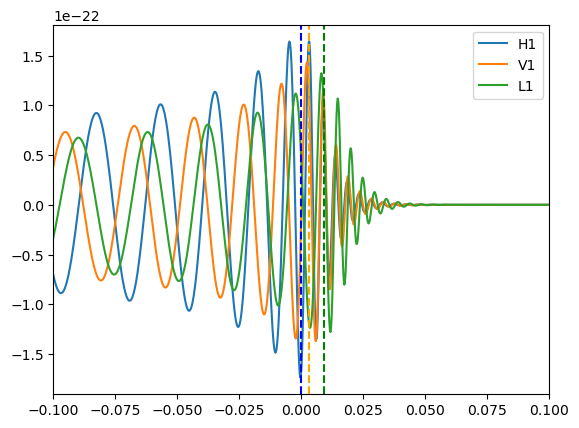

In [17]:
plt.plot(Likelihood_obj.Time_array_per_detector["H1"], Likelihood_obj.Data_list["H1"], label="H1")
plt.plot(Likelihood_obj.Time_array_per_detector["V1"], Likelihood_obj.Data_list["V1"], label="V1")
plt.plot(Likelihood_obj.Time_array_per_detector["L1"], Likelihood_obj.Data_list["L1"], label="L1")
plt.axvline(Likelihood_obj.t_delay_injection_dict["H1"], color="Blue", linestyle="dashed")
plt.axvline(Likelihood_obj.t_delay_injection_dict["V1"], color="orange", linestyle="dashed")
plt.axvline(Likelihood_obj.t_delay_injection_dict["L1"], color="green", linestyle="dashed")
plt.legend()
plt.xlim(-0.1,0.1)

(-0.1, 0.1)

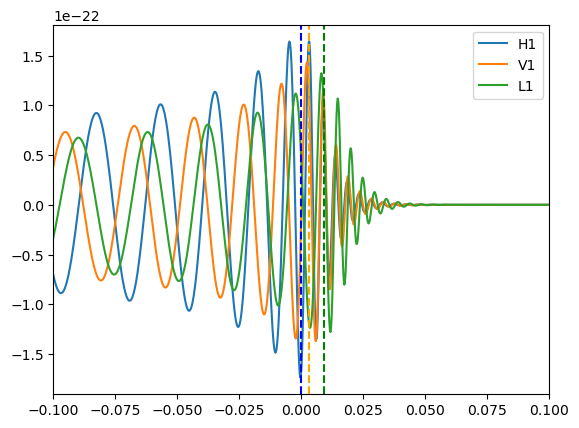

In [18]:
plt.plot(Likelihood_obj.Time_array_per_detector["H1"], Likelihood_obj_exact.Data_list["H1"], label="H1")
plt.plot(Likelihood_obj.Time_array_per_detector["V1"], Likelihood_obj_exact.Data_list["V1"], label="V1")
plt.plot(Likelihood_obj.Time_array_per_detector["L1"], Likelihood_obj_exact.Data_list["L1"], label="L1")
plt.axvline(Likelihood_obj_exact.t_delay_injection_dict["H1"], color="Blue", linestyle="dashed")
plt.axvline(Likelihood_obj_exact.t_delay_injection_dict["V1"], color="orange", linestyle="dashed")
plt.axvline(Likelihood_obj_exact.t_delay_injection_dict["L1"], color="green", linestyle="dashed")
plt.legend()
plt.xlim(-0.1,0.1)

/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(-0.1, 0.1)

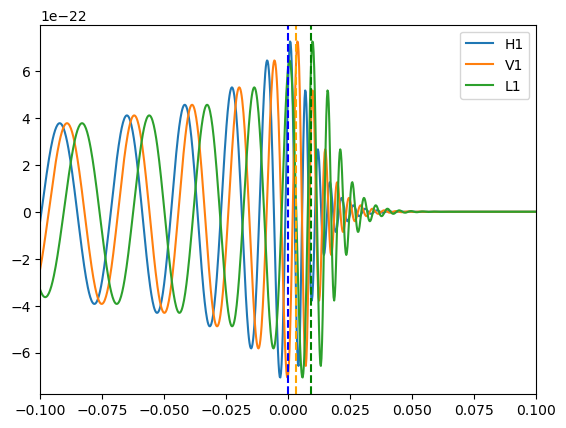

In [19]:
plt.plot(Likelihood_obj.Time_array_per_detector["H1"], Likelihood_obj.h22_fiducial["H1"], label="H1")
plt.plot(Likelihood_obj.Time_array_per_detector["V1"], Likelihood_obj.h22_fiducial["V1"], label="V1")
plt.plot(Likelihood_obj.Time_array_per_detector["L1"], Likelihood_obj.h22_fiducial["L1"], label="L1")
plt.axvline(Likelihood_obj.t_delay_injection_dict["H1"], color="Blue", linestyle="dashed")
plt.axvline(Likelihood_obj.t_delay_injection_dict["V1"], color="orange", linestyle="dashed")
plt.axvline(Likelihood_obj.t_delay_injection_dict["L1"], color="green", linestyle="dashed")
plt.legend()
plt.xlim(-0.1,0.1)

(-0.1, 0.1)

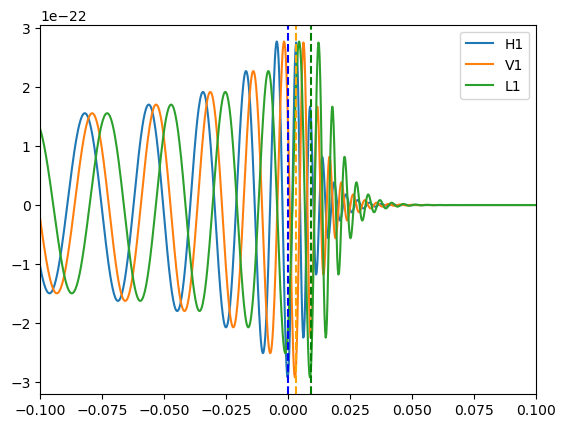

In [20]:
plt.plot(Likelihood_obj.Time_array_per_detector["H1"], Likelihood_obj.h_injection["H1"], label="H1")
plt.plot(Likelihood_obj.Time_array_per_detector["V1"], Likelihood_obj.h_injection["V1"], label="V1")
plt.plot(Likelihood_obj.Time_array_per_detector["L1"], Likelihood_obj.h_injection["L1"], label="L1")
plt.axvline(Likelihood_obj.t_delay_injection_dict["H1"], color="Blue", linestyle="dashed")
plt.axvline(Likelihood_obj.t_delay_injection_dict["V1"], color="orange", linestyle="dashed")
plt.axvline(Likelihood_obj.t_delay_injection_dict["L1"], color="green", linestyle="dashed")
plt.legend()
plt.xlim(-0.1,0.1)

In [21]:
Likelihood_obj.parameters.update(fiducial_parameters)
Likelihood_obj.log_likelihood_ratio()

np.float64(79.04279129838875)

In [22]:
Likelihood_obj.parameters.update(injection_parameters)
Likelihood_obj.log_likelihood_ratio()

np.float64(79.04279129838875)

In [23]:
Likelihood_obj_exact.parameters.update(fiducial_parameters)
Likelihood_obj_exact.log_likelihood_ratio()

np.float64(79.04372375781898)

In [24]:
Likelihood_obj_exact.parameters.update(injection_parameters)
Likelihood_obj_exact.log_likelihood_ratio()

np.float64(79.04372375781898)

In [25]:
import pandas as pd

In [26]:
SNR_tuple = (SNR_bilby, SNR, SNR_exact)
df = pd.DataFrame(SNR_tuple, index = ["Bilby SNR (FD)", "Heterodyning SNR (TD)", "Exact SNR (TD)"])
print(df.round(4))

                           H1      L1      V1
Bilby SNR (FD)         8.8624  6.7661  5.6534
Heterodyning SNR (TD)  8.9200  6.8099  5.6697
Exact SNR (TD)         8.9200  6.8099  5.6697


In [27]:
del_mc = (
    (1.2e-4) * injection_parameters["chirp_mass"] ** (8 / 3) * (10 / Network_SNR)*5
)  # Using https://arxiv.org/pdf/gr-qc/9402014 (with extra factor of 100)

if del_mc < 2.0:
    del_mc = 2.0

mc_min = injection_parameters["chirp_mass"] - del_mc
mc_max = injection_parameters["chirp_mass"] + del_mc

priors["chirp_mass"] = bilby.core.prior.Uniform(
    minimum=mc_min,
    maximum=mc_max,
    name="chirp_mass",
    latex_label="$\\mathcal{M}$",
)

In [28]:
Exact_logl = []
Approx_logl = []
parameters =  injection_parameters.copy()
params = []
Full_params_dict = []
key = 'H1_time'
for i in range(500):
    parameters[key] = priors.sample()[key]
    Likelihood_obj.parameters.update(parameters)
    Approx_logl.append(Likelihood_obj.log_likelihood_ratio())

    Likelihood_obj_exact.parameters.update(parameters)
    Exact_logl.append(Likelihood_obj_exact.log_likelihood_ratio())
    
    params.append(parameters[key])
    Full_params_dict.append(parameters)

Exact_logl = np.array(Exact_logl)
Approx_logl = np.array(Approx_logl)

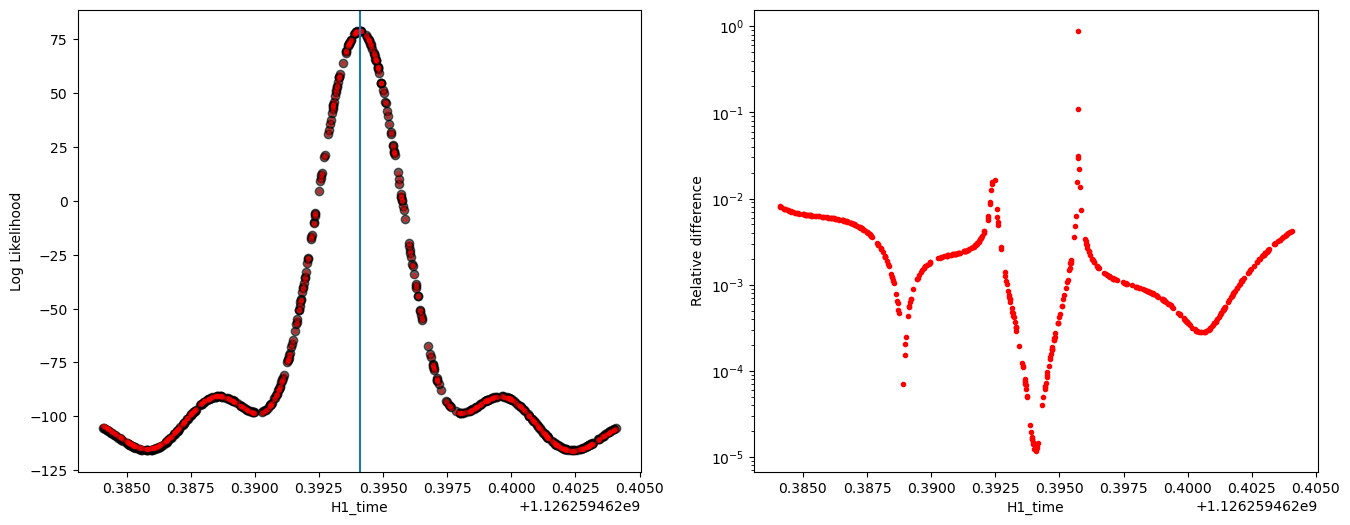

In [29]:
fig, ax = plt.subplots(1,2,figsize=(16,6))
ax[0].scatter(params,Exact_logl,alpha=0.6,color = "black",label = "Exact Likelihood")
ax[0].axvline(fiducial_parameters[key])
ax[0].scatter(params,Approx_logl,alpha=0.4,marker=".",color = "red",label = "Relative Binning")
ax[0].set_xlabel(key)
ax[0].set_ylabel("Log Likelihood")

ax[1].scatter(params,np.abs((Exact_logl-Approx_logl)/(Exact_logl)),marker=".",color = "red")
ax[1].set_xlabel(key)
ax[1].set_ylabel("Relative difference")
ax[1].set_yscale("log")

In [30]:
Likelihood_obj.noise_log_likelihood(),Likelihood_obj_exact.noise_log_likelihood()

(np.float64(-79.04372377669904), np.float64(-79.04372377669904))